In [1]:
import torch
print(torch.cuda.is_available())

True


In [2]:
import os
from dotenv import load_dotenv,find_dotenv

load_dotenv(find_dotenv(),override=True)
# assert os.getenv("MODEL"),"模型GG"
# MODEL = os.getenv("MODEL")
GROQ_API_KEY = os.getenv("GROQ_API_KEY")
GROQ_API_BASE = os.getenv("GROQ_API_BASE")
GROQ_API_MODEL = os.getenv("GROQ_API_MODEL")

assert GROQ_API_KEY, "没有读取到 GROQ_API_KEY"
assert GROQ_API_BASE, "没有读取到 GROQ_API_BASE"
assert GROQ_API_MODEL, "没有读取到 GROQ_API_MODEL"

print("环境变量读取成功")

环境变量读取成功


In [3]:
%matplotlib qt

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.widgets import RangeSlider,TextBox  # 引入范围滑动条组件
from scipy.signal import convolve2d
import scipy.io as sio

In [4]:
from typing import TypedDict, Annotated, List, Literal
import operator
import json
import uuid
from datetime import datetime
from pathlib import Path

from langchain_core.tools import tool
from langchain_openai import ChatOpenAI
from langchain_core.messages import BaseMessage, HumanMessage, SystemMessage, AIMessage

from IPython.display import Image, display

from langgraph.graph import StateGraph, START, END
from langgraph.graph import MessagesState
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode, InjectedState
from langgraph.prebuilt import tools_condition

from assets.cnn.Unet import Unet
from assets.bnn.bunetPP import UNetPlusPlus


In [5]:
# =========================
# 2. 模型缓存与结果文件存储
# =========================

# CNN 模型缓存
global_cnn_model = None
global_cnn_model_path = None
global_cnn_model_device = None

DEFAULT_CNN_MODEL_PATH = os.path.join("assets", "cnn", "model.pth")

global_bnn_model = None
global_bnn_model_path = None
global_bnn_model_device = None

DEFAULT_BNN_MODEL_PATH = os.path.join("assets", "bnn", "model.pth")

RUNS_ROOT = Path("runs")


def crop_to_divisible_by_32(un_phase: np.ndarray) -> np.ndarray:
    """
    将输入二维矩阵裁剪成行列都能被32整除的最大尺寸。
    """
    target_rows = un_phase.shape[0] - (un_phase.shape[0] % 32)
    target_cols = un_phase.shape[1] - (un_phase.shape[1] % 32)

    rows_to_crop = un_phase.shape[0] - target_rows
    cols_to_crop = un_phase.shape[1] - target_cols

    top_crop = rows_to_crop // 2
    bottom_crop = rows_to_crop - top_crop
    left_crop = cols_to_crop // 2
    right_crop = cols_to_crop - left_crop

    if bottom_crop == 0:
        cropped_phase = un_phase[top_crop:, :]
    else:
        cropped_phase = un_phase[top_crop:-bottom_crop, :]

    if right_crop == 0:
        cropped_phase = cropped_phase[:, left_crop:]
    else:
        cropped_phase = cropped_phase[:, left_crop:-right_crop]

    return cropped_phase


def load_cnn_model(device: torch.device, model_path: str = DEFAULT_CNN_MODEL_PATH):
    global global_cnn_model, global_cnn_model_path, global_cnn_model_device

    device_str = str(device)

    if (
        global_cnn_model is not None
        and global_cnn_model_path == model_path
        and global_cnn_model_device == device_str
    ):
        return global_cnn_model

    net = Unet()
    net.load_state_dict(torch.load(model_path, map_location=device))
    net.to(device)
    net.eval()

    global_cnn_model = net
    global_cnn_model_path = model_path
    global_cnn_model_device = device_str
    return net


def load_bnn_model(device: torch.device, model_path: str = DEFAULT_BNN_MODEL_PATH):
    global global_bnn_model, global_bnn_model_path, global_bnn_model_device

    device_str = str(device)

    if (
        global_bnn_model is not None
        and global_bnn_model_path == model_path
        and global_bnn_model_device == device_str
    ):
        return global_bnn_model

    net = UNetPlusPlus()
    net.load_state_dict(torch.load(model_path, map_location=device))
    net.to(device)
    net.eval()

    global_bnn_model = net
    global_bnn_model_path = model_path
    global_bnn_model_device = device_str
    return net


def make_vector_result_key(
    Nx: int,
    Nz: int,
    g: int,
    bandwidth: float,
    Lambda: float,
    n: float,
) -> str:
    return f"vector_g={g}_Nx={Nx}_Nz={Nz}"


def make_cnn_result_key() -> str:
    return "cnn"


def make_bnn_result_key(MC_test: int) -> str:
    return f"bnn|MC_test={MC_test}"


def make_run_dir() -> str:
    """
    为每一次应变子图调用创建独立运行目录。
    """
    run_id = datetime.now().strftime("%Y%m%d_%H%M%S") + "_" + uuid.uuid4().hex[:8]
    run_dir = RUNS_ROOT / run_id
    run_dir.mkdir(parents=True, exist_ok=True)
    return str(run_dir)


def sanitize_filename(name: str) -> str:
    """
    把 result_key / 文件名转成适合作为本地文件名的字符串。
    """
    invalid_chars = '<>:"/\\|?*'
    for ch in invalid_chars:
        name = name.replace(ch, "_")
    return name.replace(" ", "_")


def make_result_base_name(file_path: str, result_key: str) -> str:
    stem = Path(file_path).stem
    safe_key = sanitize_filename(result_key)
    return f"{stem}_{safe_key}"


def save_array_result(
    run_dir: str,
    file_path: str,
    result_key: str,
    array: np.ndarray,
) -> dict:
    """
    保存单个矩阵结果，例如 vector / cnn。
    返回轻量 result_ref。
    """
    base_name = make_result_base_name(file_path, result_key)
    result_path = Path(run_dir) / f"{base_name}.npy"

    np.save(result_path, array)

    return {
        "file_path": file_path,
        "result_key": result_key,
        "result_path": str(result_path),
        "kind": "array",
        "shape": list(array.shape),
    }


def save_bnn_result(
    run_dir: str,
    file_path: str,
    result_key: str,
    strain: np.ndarray,
    epistemic_uncertainty: np.ndarray,
) -> dict:
    """
    保存 BNN 多输出结果。
    """
    base_name = make_result_base_name(file_path, result_key)
    result_path = Path(run_dir) / f"{base_name}.npz"

    np.savez(
        result_path,
        strain=strain,
        epistemic_uncertainty=epistemic_uncertainty,
    )

    return {
        "file_path": file_path,
        "result_key": result_key,
        "result_path": str(result_path),
        "kind": "bnn",
        "outputs": {
            "strain": {
                "shape": list(strain.shape),
            },
            "epistemic_uncertainty": {
                "shape": list(epistemic_uncertainty.shape),
            },
        },
    }


def load_result_ref(ref: dict):
    """
    根据 result_ref 读取实际矩阵。
    """
    if ref["kind"] == "array":
        return np.load(ref["result_path"])

    if ref["kind"] == "bnn":
        return np.load(ref["result_path"])

    raise ValueError(f"未知结果类型: {ref['kind']}")


In [6]:
# =========================
# 3. 可视化函数
# =========================
def visualize_matrix_interactive(
    data,
    title="Interactive Visualization",
    cmap="jet",
    init_range=(-1.0, 1.0),
):
    fig, ax = plt.subplots(figsize=(9, 7))
    plt.subplots_adjust(bottom=0.3)

    d_min, d_max = np.nanmin(data), np.nanmax(data)
    vmin, vmax = init_range

    if vmin >= vmax or vmin < d_min or vmax > d_max:
        vmin, vmax = d_min, d_max

    img = ax.imshow(data, cmap=cmap, vmin=vmin, vmax=vmax, aspect="auto")
    ax.set_title(title)
    fig.colorbar(img, ax=ax)

    slider_ax = fig.add_axes([0.2, 0.15, 0.6, 0.03])
    ax_box_min = fig.add_axes([0.2, 0.05, 0.15, 0.04])
    ax_box_max = fig.add_axes([0.65, 0.05, 0.15, 0.04])

    color_slider = RangeSlider(slider_ax, "Range", d_min, d_max, valinit=(vmin, vmax))
    text_min = TextBox(ax_box_min, "Min: ", initial=f"{vmin:.2f}")
    text_max = TextBox(ax_box_max, "Max: ", initial=f"{vmax:.2f}")

    def update_display(new_vmin, new_vmax):
        img.set_clim(new_vmin, new_vmax)
        fig.canvas.draw_idle()

    color_slider.on_changed(lambda val: update_display(val[0], val[1]))

    def on_text_submit(_):
        try:
            new_vmin = float(text_min.text)
            new_vmax = float(text_max.text)
            if new_vmin < new_vmax:
                color_slider.set_val((new_vmin, new_vmax))
                update_display(new_vmin, new_vmax)
        except ValueError:
            pass

    text_min.on_submit(on_text_submit)
    text_max.on_submit(on_text_submit)

    fig.interacts = [color_slider, text_min, text_max]
    plt.show(block=False)

# tool

In [7]:
# =========================
# 4. 工具：矢量法
# =========================
@tool
def vector_method_g(
    file_path: str,
    run_dir: Annotated[str, InjectedState("run_dir")],
    Nx: int = 25,
    Nz: int = 25,
    g: int = 1,
    bandwidth: float = 50e-9,
    Lambda: float = 840e-9,
    n: float = 1.0,
):
    """
    矢量法应变计算工具。
    当用户要求使用矢量法进行应变计算时调用。

    参数:
        file_path: 待处理的 .mat 相位文件绝对路径。
        Nx: 横向窗口大小。
        Nz: 轴向（纵向）窗口大小。
        g: 步长。
        bandwidth: 带宽 (m)。
        Lambda: 波长 (m)。
        n: 折射率。

    返回:
        执行状态说明。
    """
    try:
        result_key = make_vector_result_key(Nx, Nz, g, bandwidth, Lambda, n)

        mat_data = sio.loadmat(file_path)
        var_names = [k for k in mat_data.keys() if not k.startswith("_")]
        if not var_names:
            return f"矢量法计算失败：文件 {file_path} 中没有可用变量。"

        Det_Phase = mat_data[var_names[0]]

        p1 = (Lambda ** 2) / bandwidth
        phase_data = np.array(Det_Phase, dtype=float)
        phase_data[phase_data == 0] = np.nan

        kernel_x = np.ones((1, Nx)) / Nx
        complex_phase = np.exp(1j * phase_data)
        B = convolve2d(complex_phase, kernel_x, mode="valid")
        B_model, B_angle = np.abs(B), np.angle(B)

        rows, cols = B_angle.shape
        valid_g = min(g, rows - 1)
        if valid_g < 1:
            return f"矢量法计算失败：文件 {file_path} 的数据行数不足。"

        phase_diff = B_angle[valid_g:, :] - B_angle[:-valid_g, :]
        C = B_model[:-valid_g, :] * B_model[valid_g:, :] * np.exp(1j * phase_diff)
        Cnorm_angle = np.angle(C) / valid_g

        kernel_z = np.ones((Nz, 1)) / Nz
        avg_phase = np.angle(convolve2d(np.exp(1j * Cnorm_angle), kernel_z, mode="valid"))

        Weiyi = Lambda * avg_phase / (4 * np.pi * n)
        strain = Weiyi * 1e3 / p1
        strain = np.nan_to_num(strain, nan=0.0)

        ref = save_array_result(
            run_dir=run_dir,
            file_path=file_path,
            result_key=result_key,
            array=strain,
        )

        return json.dumps(
            {
                "status": "success",
                "method": "vector",
                "ref": ref,
            },
            ensure_ascii=False,
        )

    except Exception as e:
        return f"矢量法计算过程中发生错误: {str(e)}"


In [8]:
# =========================
# 5. 工具：CNN
# =========================
@tool
def cnn_method(
    file_path: str,
    run_dir: Annotated[str, InjectedState("run_dir")],
    device_str: str = "cuda:0",
):
    """
    CNN应变计算工具。
    当用户要求使用“CNN方法”、“深度学习方法”、“Unet方法”进行应变计算时调用。

    参数:
        file_path: 待处理的 .mat 相位文件绝对路径。
        device_str: 推理设备，默认 cuda:0，不可用时自动退回 cpu。

    返回:
        执行状态说明。
    """
    try:
        result_key = make_cnn_result_key()

        if device_str.startswith("cuda") and torch.cuda.is_available():
            device = torch.device(device_str)
        else:
            device = torch.device("cpu")

        if not os.path.exists(DEFAULT_CNN_MODEL_PATH):
            return f"CNN计算过程中发生错误: 未找到模型文件 {DEFAULT_CNN_MODEL_PATH}"

        net = load_cnn_model(device, DEFAULT_CNN_MODEL_PATH)

        mat_data = sio.loadmat(file_path)
        var_names = [k for k in mat_data.keys() if not k.startswith("__")]
        if len(var_names) != 1:
            return f"CNN计算过程中发生错误: 文件 {file_path} 中变量数量不为1。"

        wrapped_data = mat_data[var_names[0]]

        image = np.transpose(wrapped_data)
        image = torch.from_numpy(
            image.reshape(1, 1, image.shape[0], image.shape[1])
        ).to(device=device, dtype=torch.float32)

        with torch.no_grad():
            strain = net(image)

        strain = strain.squeeze().cpu().detach().numpy()
        strain = np.transpose(np.array(strain))

        ref = save_array_result(
            run_dir=run_dir,
            file_path=file_path,
            result_key=result_key,
            array=strain,
        )

        return json.dumps(
            {
                "status": "success",
                "method": "cnn",
                "ref": ref,
            },
            ensure_ascii=False,
        )

    except Exception as e:
        return f"CNN计算过程中发生错误: {str(e)}"


In [9]:
@tool
def bnn_method(
    file_path: str,
    run_dir: Annotated[str, InjectedState("run_dir")],
    MC_test: int = 50,
    device_str: str = "cuda:0",
):
    """
    BNN应变计算工具。
    当用户要求使用“BNN方法”、“贝叶斯神经网络方法”、“深度学习BNN方法”进行应变计算时调用。

    参数:
        file_path: 待处理的 .mat 相位文件绝对路径。
        MC_test: Monte Carlo采样次数，默认50。
        device_str: 推理设备，默认 cuda:0，不可用时自动退回 cpu。

    返回:
        执行状态说明。
    """
    try:
        result_key = make_bnn_result_key(MC_test)

        if device_str.startswith("cuda") and torch.cuda.is_available():
            device = torch.device(device_str)
        else:
            device = torch.device("cpu")

        if not os.path.exists(DEFAULT_BNN_MODEL_PATH):
            return f"BNN计算过程中发生错误: 未找到模型文件 {DEFAULT_BNN_MODEL_PATH}"

        net = load_bnn_model(device, DEFAULT_BNN_MODEL_PATH)

        mat_data = sio.loadmat(file_path)
        var_names = [k for k in mat_data.keys() if not k.startswith("__")]
        if len(var_names) != 1:
            return f"BNN计算过程中发生错误: 文件 {file_path} 中变量数量不为1。"

        wrapped_data = mat_data[var_names[0]]
        wrapped_data = crop_to_divisible_by_32(wrapped_data)

        image = np.transpose(wrapped_data)
        image = torch.from_numpy(
            image.reshape(1, 1, image.shape[0], image.shape[1])
        ).to(device=device, dtype=torch.float32)

        means = []
        log_vars = []

        with torch.no_grad():
            for _ in range(MC_test):
                mean, log_var, _ = net(image)
                means.append(mean)
                log_vars.append(log_var)

        means = torch.stack(means)
        log_vars = torch.stack(log_vars)

        # 应变：对 mean 求 MC 平均
        predicts = torch.mean(means, dim=0).squeeze()
        predicts = predicts.cpu().detach().numpy()
        strain = np.transpose(np.array(predicts))

        # 模型不确定度：epistemic uncertainty
        epistemic_uncertainty = torch.var(means, dim=0).squeeze()
        epistemic_uncertainty = epistemic_uncertainty.cpu().detach().numpy() ** 0.5
        epistemic_uncertainty = np.transpose(np.array(epistemic_uncertainty))

        ref = save_bnn_result(
            run_dir=run_dir,
            file_path=file_path,
            result_key=result_key,
            strain=strain,
            epistemic_uncertainty=epistemic_uncertainty,
        )

        return json.dumps(
            {
                "status": "success",
                "method": "bnn",
                "ref": ref,
            },
            ensure_ascii=False,
        )

    except Exception as e:
        return f"BNN计算过程中发生错误: {str(e)}"


In [10]:
# =========================
# 6. 模型
# =========================
tools = [vector_method_g, cnn_method, bnn_method]

llm_tool = ChatOpenAI(
    model=GROQ_API_MODEL,
    api_key=GROQ_API_KEY,
    base_url=GROQ_API_BASE,
    temperature=0,
).bind_tools(tools)

llm = ChatOpenAI(
    model=GROQ_API_MODEL,
    api_key=GROQ_API_KEY,
    base_url=GROQ_API_BASE,
    temperature=0,
)

# node

In [11]:
# StrainGraphState 已迁移到下方节点定义 cell。
# messages 使用 add_messages，result_refs 使用 operator.add。


In [12]:
# =========================
# 7. State 与节点：应变助手
#    让它自己决定是否继续调用工具
# =========================
class StrainGraphState(TypedDict):
    messages: Annotated[List[BaseMessage], add_messages]

    # 每次应变任务独立目录
    run_dir: str

    # 当前已经完成的结果引用，不存大矩阵
    result_refs: Annotated[List[dict], operator.add]


def init_run_context(state: StrainGraphState):
    """
    每次进入应变子图时，创建本次运行目录。
    不清空任何全局变量。
    """
    run_dir = make_run_dir()

    return {
        "run_dir": run_dir,
        "result_refs": [],
    }


def strain_assistant(state: StrainGraphState):
    run_dir = state["run_dir"]
    result_refs = state.get("result_refs", [])

    if result_refs:
        summary_text = "；".join(
            [
                f"{Path(ref['file_path']).name}: {ref['result_key']}"
                for ref in result_refs
            ]
        )
    else:
        summary_text = "当前还没有任何已完成的应变结果。"

    sys_msg = SystemMessage(
        content=(
            "你是一个应变计算助手，拥有三种应变计算工具：\n"
            "1. vector_method_g：矢量法，可带参数 Nx、Nz、g、bandwidth、Lambda、n\n"
            "2. cnn_method：深度学习CNN方法\n"
            "3. bnn_method：深度学习BNN方法，可带参数 MC_test，输出应变和模型不确定度\n\n"
            "规则：\n"
            "1. 你要根据用户要求决定调用哪个工具。\n"
            "2. 如果用户要求多个方法或同一方法的不同参数版本，就逐个调用，但每次只能调用一个工具。\n"
            "3. run_dir 由系统自动注入工具参数，你不需要也不能自己编造 run_dir。\n"
            "4. 对于同一个文件、同一种方法、同一组参数，不要重复调用。\n"
            "5. 如果用户要求的方法都已经完成，就不要再调用工具。\n"
            "6. “步长3”表示 g=3。\n"
            "7. 如果用户说 BNN 方法、贝叶斯神经网络方法，就调用 bnn_method。\n\n"
            f"当前 run_dir：{run_dir}\n"
            f"当前已经完成的结果摘要：{summary_text}"
        )
    )

    response = llm_tool.invoke([sys_msg] + state["messages"])
    return {"messages": [response]}


def collect_result_refs(state: StrainGraphState):
    """
    从工具返回的 ToolMessage 里提取 ref，写入 result_refs。
    """
    refs = []

    for msg in reversed(state["messages"]):
        if getattr(msg, "type", "") != "tool":
            continue

        content = msg.content

        try:
            data = json.loads(content)
        except Exception:
            continue

        if isinstance(data, dict) and data.get("status") == "success" and "ref" in data:
            refs.append(data["ref"])

    # reversed 是从后往前扫，这里再反转回来
    refs = list(reversed(refs))

    # 去重，避免同一个 tool message 被重复收集
    old_paths = {
        ref.get("result_path")
        for ref in state.get("result_refs", [])
    }

    new_refs = [
        ref for ref in refs
        if ref.get("result_path") not in old_paths
    ]

    if not new_refs:
        return {}

    return {
        "result_refs": new_refs
    }


# =========================
# 8. 节点：判断是否可视化
#    规则：用户没明确拒绝就默认展示
# =========================
def judge_visualize(state: StrainGraphState):
    user_text = ""
    for msg in state["messages"]:
        if getattr(msg, "type", "") == "human":
            user_text = msg.content

    negative_keywords = [
        "不展示图", "不要展示图", "不用展示图",
        "不看图", "不要看图", "不用看图",
        "不需要可视化", "不要可视化", "不用可视化",
        "不显示图", "不要显示图", "不用显示图"
    ]

    if any(k in user_text for k in negative_keywords):
        return {"messages": [AIMessage(content="可视化判断：否")]}

    sys_msg = SystemMessage(
        content=(
            "你是一个判断器，只能输出“是”或“否”。"
            "除非用户明确拒绝看图，否则一律输出“是”。"
        )
    )

    resp = llm.invoke([
        sys_msg,
        HumanMessage(content=user_text)
    ])

    text = resp.content.strip()
    result = "否" if text == "否" else "是"

    return {"messages": [AIMessage(content=f"可视化判断：{result}")]}


# =========================
# 9. 节点：依次可视化所有已得到的结果
#    不改你的可视化函数，只顺序调用
# =========================
def visualize_node(state: StrainGraphState):
    result_refs = state.get("result_refs", [])

    if not result_refs:
        return {"messages": [AIMessage(content="没有可视化结果。")]}

    shown_msgs = []

    for ref in result_refs:
        file_path = ref["file_path"]
        result_key = ref["result_key"]

        if ref["kind"] == "array":
            data = np.load(ref["result_path"])

            visualize_matrix_interactive(
                data,
                title=f"{os.path.basename(file_path)} | {result_key}",
                cmap="jet",
                init_range=(-1.0, 1.0),
            )

            shown_msgs.append(f"{file_path}:{result_key}")

        elif ref["kind"] == "bnn":
            data = np.load(ref["result_path"])

            strain = data["strain"]
            epistemic_uncertainty = data["epistemic_uncertainty"]

            visualize_matrix_interactive(
                strain,
                title=f"{os.path.basename(file_path)} | {result_key} | strain",
                cmap="jet",
                init_range=(-1.0, 1.0),
            )
            shown_msgs.append(f"{file_path}:{result_key}:strain")

            visualize_matrix_interactive(
                epistemic_uncertainty,
                title=f"{os.path.basename(file_path)} | {result_key} | epistemic_uncertainty",
                cmap="jet",
                init_range=(-1.0, 1.0),
            )
            shown_msgs.append(f"{file_path}:{result_key}:epistemic_uncertainty")

    return {
        "messages": [
            AIMessage(
                content=(
                    "已显示图像："
                    + "；".join(shown_msgs)
                    + f"\n结果文件保存在：{state['run_dir']}"
                )
            )
        ]
    }


In [13]:
# reset_strain_results 已移除：应变结果不再保存到全局缓存。
# 每次应变子图运行由 init_run_context 创建独立 run_dir。


# edge

In [14]:
# =========================
# 10. 路由
# =========================
def route_after_assistant(state: StrainGraphState):
    last_msg = state["messages"][-1]
    if hasattr(last_msg, "tool_calls") and last_msg.tool_calls:
        return "tools"
    return "judge_visualize"


def route_after_judge(state: StrainGraphState):
    last_msg = state["messages"][-1].content.strip()
    if "否" in last_msg:
        return END
    return "visualize"


# Graph

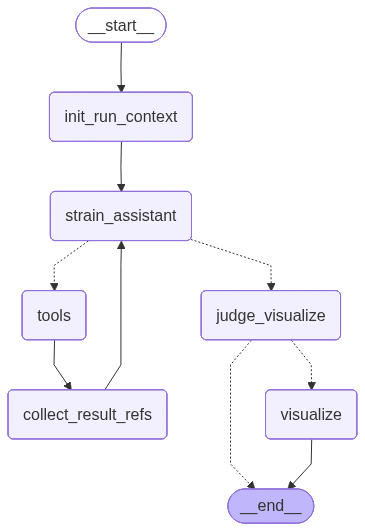

In [15]:
# =========================
# 11. ?
# =========================

tool_node = ToolNode([vector_method_g, cnn_method, bnn_method])

builder = StateGraph(StrainGraphState)

builder.add_node("init_run_context", init_run_context)
builder.add_node("strain_assistant", strain_assistant)
builder.add_node("tools", tool_node)
builder.add_node("collect_result_refs", collect_result_refs)
builder.add_node("judge_visualize", judge_visualize)
builder.add_node("visualize", visualize_node)

builder.add_edge(START, "init_run_context")
builder.add_edge("init_run_context", "strain_assistant")

builder.add_conditional_edges(
    "strain_assistant",
    route_after_assistant,
    {
        "tools": "tools",
        "judge_visualize": "judge_visualize",
    }
)

builder.add_edge("tools", "collect_result_refs")
builder.add_edge("collect_result_refs", "strain_assistant")

builder.add_conditional_edges(
    "judge_visualize",
    route_after_judge,
    {
        "visualize": "visualize",
        END: END,
    }
)

builder.add_edge("visualize", END)

strain_estimation = builder.compile()

# Show
display(Image(strain_estimation.get_graph(xray=True).draw_mermaid_png()))


In [16]:
# response = strain_eetimation.invoke(
#     {
#         "messages": [
#             HumanMessage(content="cnn,计算和矢量法应变计算，地址D:/项目/cgan/跑完的代码/data_泛化抗噪/单层拉伸/phase1.mat,D:/项目/cgan/跑完的代码/data_泛化抗噪/单层拉伸/phase2.mat。")
#         ]
#     },
#     config={"recursion_limit": 10}
# )

# response

In [16]:
class EntryGraphState(MessagesState):
    sub_agent: str


# task_assign tool
class TaskAssignment(TypedDict):
    """Decision on what task type to execute."""
    update_type: Literal['strain_estimation', 'chat']


# node
def supervisor(state: EntryGraphState):
    sys_msg = SystemMessage(
        content=(
            """
            你是一个任务执行助手，你需要根据用户的消息执行不同的任务

            可执行的任务类型：

            1. strain_estimation：可进行应变计算，具体计算方法包括矢量法，cnn,bnn

            2. chat：日常聊天

            以下是你用于分析用户消息的推理规则：

            1. 请仔细分析下方呈现的用户消息。

            2. 判断是否需要执行的任务：
                - 如果用户提到了应变计算，请调用 `TaskAssignment` 工具（参数 `update_type` 设为 `strain_estimation`）执行应变计算。
                - 如果用户没有提到应变计算，请调用 `TaskAssignment` 工具（参数 `update_type` 设为 `chat`）来正常对话。
             """
        )
    )
    response = llm.bind_tools([TaskAssignment]).invoke([sys_msg] + state["messages"])

    tool_call = response.tool_calls[0]
    if tool_call['args']['update_type'] == "strain_estimation":
        return {"sub_agent": "strain_estimation"}
    elif tool_call['args']['update_type'] == "chat":
        return {"sub_agent": "chat"}
    else:
        raise ValueError


# edge
def route_for_subagent(state: EntryGraphState) -> Literal["strain_estimation", "chat"]:
    return state["sub_agent"]


In [17]:
# chat
def chat(state: MessagesState):
    messages=state["messages"]
    result = llm.invoke(messages)

    return {"messages": [result]}
 

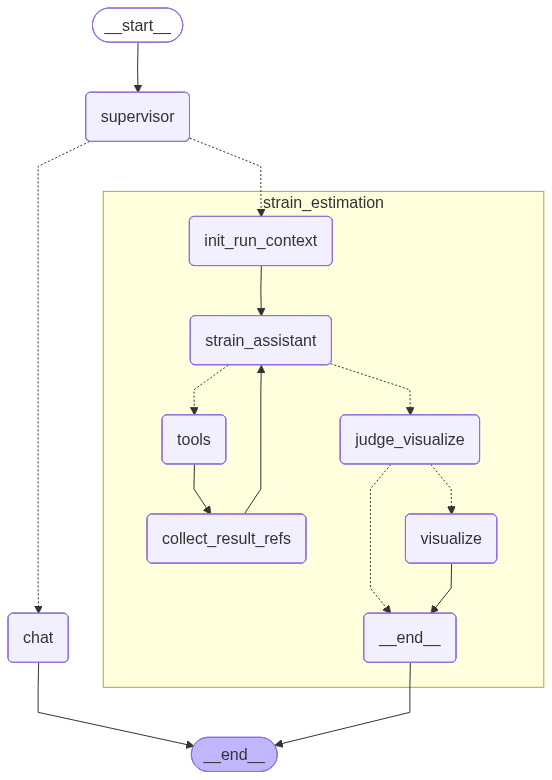

In [18]:
agent_builder = StateGraph(EntryGraphState)

agent_builder.add_node("supervisor", supervisor)
agent_builder.add_node("chat", chat)
agent_builder.add_node("strain_estimation", strain_estimation)

agent_builder.add_conditional_edges(
    "supervisor",
    route_for_subagent,
    {
        "strain_estimation": "strain_estimation",
        "chat": "chat",
    }
)
agent_builder.add_edge(START, "supervisor")
agent_builder.add_edge("chat", END)
agent_builder.add_edge("strain_estimation", END)

OCT_agent = agent_builder.compile()

# Show
display(Image(OCT_agent.get_graph(xray=True).draw_mermaid_png()))


In [19]:
response = OCT_agent.invoke(
    {
        "messages": [
            HumanMessage(content="cnn,,计算和矢量法应变计算，地址D:/项目/cgan/跑完的代码/data_泛化抗噪/单层拉伸/phase1.mat,D:/项目/cgan/跑完的代码/data_泛化抗噪/单层拉伸/phase2.mat。")
        ]
    },
    config={"recursion_limit": 20}
)

response

{'messages': [HumanMessage(content='cnn,,计算和矢量法应变计算，地址D:/项目/cgan/跑完的代码/data_泛化抗噪/单层拉伸/phase1.mat,D:/项目/cgan/跑完的代码/data_泛化抗噪/单层拉伸/phase2.mat。', additional_kwargs={}, response_metadata={}, id='a2e70f37-23a5-484c-a6cf-d2456f078f02'),
  AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 562, 'prompt_tokens': 1052, 'total_tokens': 1614, 'completion_tokens_details': {'accepted_prediction_tokens': None, 'audio_tokens': None, 'reasoning_tokens': 256, 'rejected_prediction_tokens': None}, 'prompt_tokens_details': None, 'queue_time': 0.022189276, 'prompt_time': 0.048676353, 'completion_time': 0.974083219, 'total_time': 1.022759572}, 'model_provider': 'openai', 'model_name': 'qwen/qwen3-32b', 'system_fingerprint': 'fp_d58dbe76cd', 'id': 'chatcmpl-b19531a2-d90b-417f-a81e-629a604df4f4', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019dce60-9627-7d73-a16d-04257559ad81-0', tool_calls=[{'name':

In [21]:
response = OCT_agent.invoke(
    {
        "messages": [
            HumanMessage(content="步长3的矢量法应变计算，地址D:/项目/cgan/跑完的代码/data_泛化抗噪/单层拉伸/phase1.mat")
        ]
    },
    config={"recursion_limit": 10}
)

response

{'messages': [HumanMessage(content='步长3的矢量法应变计算，地址D:/项目/cgan/跑完的代码/data_泛化抗噪/单层拉伸/phase1.mat', additional_kwargs={}, response_metadata={}, id='7cc489f3-ad66-43ce-8050-2ed1d369bb01'),
  AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 240, 'prompt_tokens': 1023, 'total_tokens': 1263, 'completion_tokens_details': {'accepted_prediction_tokens': None, 'audio_tokens': None, 'reasoning_tokens': 184, 'rejected_prediction_tokens': None}, 'prompt_tokens_details': None, 'queue_time': 0.021141225, 'prompt_time': 0.046684804, 'completion_time': 0.456648294, 'total_time': 0.503333098}, 'model_provider': 'openai', 'model_name': 'qwen/qwen3-32b', 'system_fingerprint': 'fp_d58dbe76cd', 'id': 'chatcmpl-de7d3a8f-d4cc-41f0-a93b-9d5c09b3e050', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019dce61-98fe-7bb1-a82a-afd3a52fa279-0', tool_calls=[{'name': 'vector_method_g', 'args': {'file_path': 'D:/项目